# 01 Dataset Exploration

## Setup and imports

In [1]:
import sys

COLAB = "google.colab" in sys.modules

# Environment Setup
if COLAB:
    print("Running in Google Colab. Setting up environment...")
    BASE_DIR = './'  # In Colab, everything stays inside /content/

    import gdown
    requirements_ID = '1XHtGbTN-NEHnvAyM7ufYi4mw0K2lN9NN'
    gdown.download(id=requirements_ID, output='requirements.txt', quiet=False)
    %pip install -r "requirements.txt"
else:
    print("Running locally. Assuming files are already present.")
    BASE_DIR = '../' # Locally, everything is one level up from /src

    requirements_path = "./../requirements.txt"
    %pip install -r "{requirements_path}"

Running in Google Colab. Setting up environment...


Downloading...
From: https://drive.google.com/uc?id=1XHtGbTN-NEHnvAyM7ufYi4mw0K2lN9NN
To: /content/requirements.txt
100%|██████████| 129/129 [00:00<00:00, 209kB/s]


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.4/83.4 kB 1.7 MB/s eta 0:00:0000:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.1/179.1 kB 3.5 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 33.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 18.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 6.3 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.3/129.3 kB 3.2 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import gdown
import zipfile
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import joblib

## Dataset download and extraction

In [3]:
# Dataset Download
dataset_zip_ID = '1GXFCCkpY0Nwhen4GQ4yl0XhdAIimlukZ'
dataset_dir = os.path.join(BASE_DIR, 'data') 
dataset_zip_path = os.path.join(dataset_dir, 'wisdm-dataset.zip')

if not os.path.exists(dataset_zip_path):
    print(f"Dataset not found at {dataset_zip_path}. Downloading...")
    os.makedirs(dataset_dir, exist_ok=True)
        
    gdown.download(id=dataset_zip_ID, output=dataset_zip_path, quiet=False)
    print("Download complete!")
else:
    print(f"Dataset already exists at {dataset_zip_path}. Skipping download.")

Dataset not found at ./data/wisdm-dataset.zip. Downloading...


Downloading...
From (original): https://drive.google.com/uc?id=1GXFCCkpY0Nwhen4GQ4yl0XhdAIimlukZ
From (redirected): https://drive.google.com/uc?id=1GXFCCkpY0Nwhen4GQ4yl0XhdAIimlukZ&confirm=t&uuid=20465a87-4a80-452d-bce4-698aa3d4d00e
To: /content/data/wisdm-dataset.zip
100%|██████████| 310M/310M [00:05<00:00, 61.2MB/s] 

Download complete!


In [5]:
# Dataset extraction
extract_path = os.path.join(dataset_dir, 'wisdm_data')

with zipfile.ZipFile(dataset_zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Files extracted to: {extract_path}")

Files extracted to: ./data/wisdm_data


## Loading a sample file
We load a single raw data file to inspect its structure.

In [6]:
data_file = os.path.join(extract_path, 'wisdm-dataset/raw/watch/accel/data_1600_accel_watch.txt')

# Load dataset
column_names = ['user', 'activity', 'timestamp', 'x', 'y', 'z']
df = pd.read_csv(data_file, header=None, names=column_names)

df['z'] = df['z'].astype(str).str.replace(';', '').astype(float)

display(df.head())
print(f"\nDataset dimensions: {df.shape}")

,user,activity,timestamp,x,y,z
0,1600,A,90426708196641,7.091625,-0.591667,8.195502
1,1600,A,90426757696641,4.972757,-0.158317,6.696732
2,1600,A,90426807196641,3.253720,-0.191835,6.107758
3,1600,A,90426856696641,2.801216,-0.155922,5.997625
4,1600,A,90426906196641,3.770868,-1.051354,7.731027



Dataset dimensions: (65462, 6)


## Data loading and preprocessing

### 1. Sensor Alignment and Fusion (Watch)
We load the accelerometer and gyroscope files for all users and merges them based on `user`, `activity`, and `timestamp`.

In [7]:
def load_wisdm_file(path):
    cols = ['user', 'activity', 'timestamp', 'x', 'y', 'z']
    data = pd.read_csv(path, header=None, names=cols)
    data['z'] = data['z'].astype(str).str.replace(';', '').astype(float)

    return data

In [8]:
base_path = os.path.join(extract_path, 'wisdm-dataset/raw/watch')
accel_files = sorted(glob.glob(f'{base_path}/accel/data_*_accel_watch.txt'))

all_merged_data = []

print("Starting processing for all users...")

for a_path in accel_files:
    # Extract the user ID from the file name
    user_id = os.path.basename(a_path).split('_')[1]
    g_path = f'{base_path}/gyro/data_{user_id}_gyro_watch.txt'

    if os.path.exists(g_path):
        # Load data
        df_a = load_wisdm_file(a_path)
        df_g = load_wisdm_file(g_path)

        # Rename columns
        df_a.columns = ['user', 'activity', 'timestamp', 'w_accel_x', 'w_accel_y', 'w_accel_z']
        df_g.columns = ['user', 'activity', 'timestamp', 'w_gyro_x', 'w_gyro_y', 'w_gyro_z']

        # Merge
        merged = pd.merge(df_a, df_g, on=['user', 'activity', 'timestamp'], how='inner')
        all_merged_data.append(merged)

# Concatenate all users
global_watch_df = pd.concat(all_merged_data, ignore_index=True)

print(f"Global merge completed!")
display(global_watch_df.head())

print(f"\nGlobal matrix dimensions: {global_watch_df.shape}")
print(f"Unique users processed: {global_watch_df['user'].nunique()}")

Starting processing for all users...
Global merge completed!


,user,activity,timestamp,w_accel_x,w_accel_y,w_accel_z,w_gyro_x,w_gyro_y,w_gyro_z
0,1600,A,90426757696641,4.972757,-0.158317,6.696732,0.314944,-1.022277,-0.309962
1,1600,A,90426807196641,3.253720,-0.191835,6.107758,0.387382,-0.618541,-0.048972
2,1600,A,90426856696641,2.801216,-0.155922,5.997625,0.070999,-0.209480,-0.195978
3,1600,A,90426906196641,3.770868,-1.051354,7.731027,0.037975,0.254976,-0.156563
4,1600,A,90426955696641,4.661511,0.169689,9.684695,0.073129,0.719431,-0.001035



Global matrix dimensions: (3368542, 9)
Unique users processed: 51


### 2. Activity Mapping
We apply the activity dictionary to the `global_watch_df` to make the data more understandable.

In [9]:
activity_map = {
    'A': 'Walking', 'B': 'Jogging', 'C': 'Stairs', 'D': 'Sitting', 'E': 'Standing',
    'F': 'Typing', 'G': 'Teeth', 'H': 'Soup', 'I': 'Chips', 'J': 'Pasta',
    'K': 'Drinking', 'L': 'Sandwich', 'M': 'Kicking', 'O': 'Catch',
    'P': 'Dribbling', 'Q': 'Writing', 'R': 'Clapping', 'S': 'Folding'
}

global_watch_df['activity_name'] = global_watch_df['activity'].map(activity_map)

print("Activity distribution in the global dataset:")
display(global_watch_df['activity_name'].value_counts())

Activity distribution in the global dataset:


,count
activity_name,
Standing,195324
Drinking,195004
Writing,192771
Sitting,192594
Pasta,188713
Dribbling,188670
Folding,188367
Chips,186339
Walking,186149


### 3. Time Window Preparation (2 seconds)
We segment the data with a 2-second window, which corresponds to 40 samples given the 20Hz sampling rate.

In [10]:
def create_windows(df, window_size=40, step_size=20):
    windows = []
    labels = []

    # Sort just to be safe
    df = df.sort_values(['user', 'activity', 'timestamp'])

    # Iterate over each user/activity combination to avoid spurious overlaps
    for (user, activity), group in df.groupby(['user', 'activity']):
        data = group[['w_accel_x', 'w_accel_y', 'w_accel_z', 'w_gyro_x', 'w_gyro_y', 'w_gyro_z']].values

        for i in range(0, len(data) - window_size + 1, step_size):
            window = data[i:i + window_size]
            windows.append(window)
            labels.append(activity)

    return np.array(windows), np.array(labels)

# Execute segmentation (we use a step of 20 to have a 50% overlap)
X, y = create_windows(global_watch_df, window_size=40, step_size=20)

print(f"Shape of input X (Windows, Samples, Channels): {X.shape}")
print(f"Shape of target y: {y.shape}")

Shape of input X (Windows, Samples, Channels): (167247, 40, 6)
Shape of target y: (167247,)


### Visualization of a Sample Window
To understand what the neural network will actually "see", let's visualize a single 2-second time window (40 samples). 
The plot below displays the 3 accelerometer axes (measuring linear acceleration in m/s²) and the 3 gyroscope axes (measuring rotational velocity in rad/s) for a specific activity.

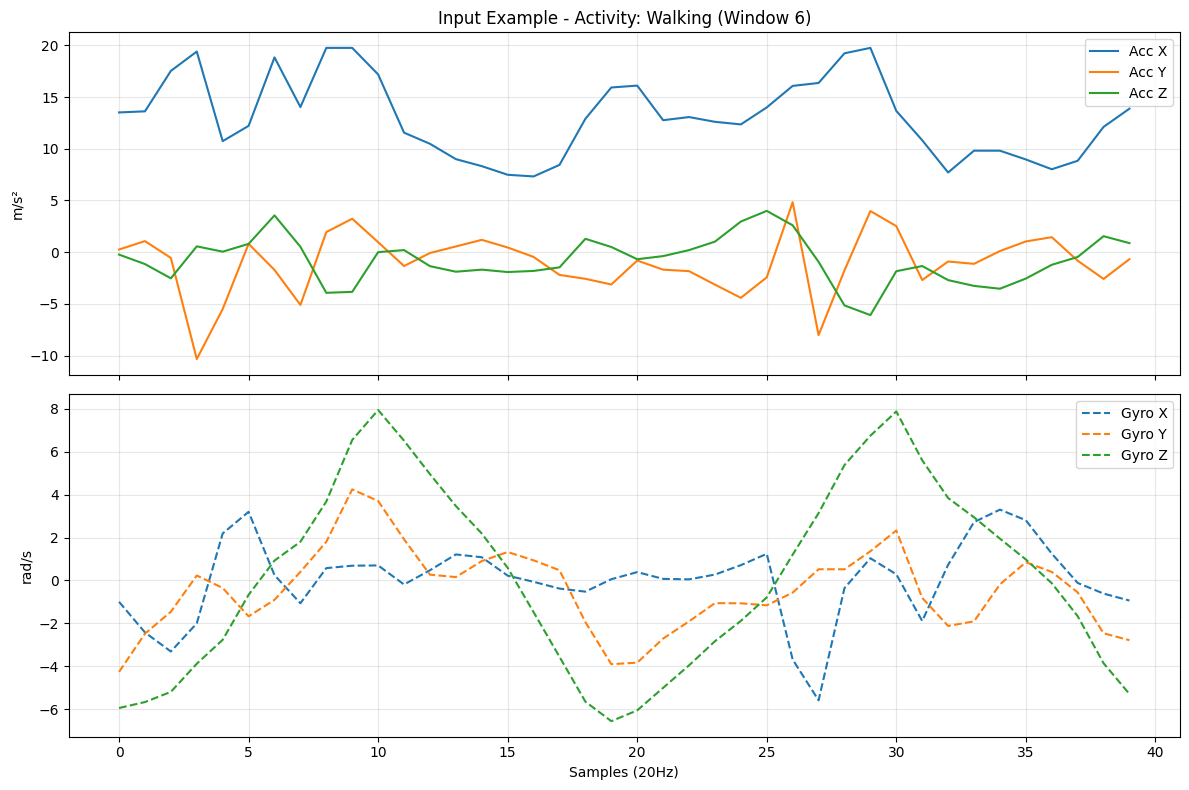

In [11]:
# Choose an example index
sample_idx = 6
sample_window = X[sample_idx]
sample_label = activity_map.get(y[sample_idx], y[sample_idx])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot Accelerometer
ax1.plot(sample_window[:, 0], label='Acc X')
ax1.plot(sample_window[:, 1], label='Acc Y')
ax1.plot(sample_window[:, 2], label='Acc Z')
ax1.set_title(f'Input Example - Activity: {sample_label} (Window {sample_idx})')
ax1.set_ylabel('m/s²')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Plot Gyroscope
ax2.plot(sample_window[:, 3], label='Gyro X', linestyle='--')
ax2.plot(sample_window[:, 4], label='Gyro Y', linestyle='--')
ax2.plot(sample_window[:, 5], label='Gyro Z', linestyle='--')
ax2.set_ylabel('rad/s')
ax2.set_xlabel('Samples (20Hz)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4. Data Normalization (Z-score Normalization)
We normalize the data so that they have a mean of 0 and a variance of 1.

In [12]:
# Reshape X for normalization: (N*40, 6)
N_windows, N_samples, N_channels = X.shape
X_reshaped = X.reshape(-1, N_channels)

# Apply StandardScaler
scaler = StandardScaler()
X_scaled_raw = scaler.fit_transform(X_reshaped)

# Restore X to its original shape (Windows, 40, 6)
X_scaled = X_scaled_raw.reshape(N_windows, N_samples, N_channels)

print(f"Mean after normalization (close to 0): {np.mean(X_scaled):.4f}")
print(f"Standard Deviation after normalization (close to 1): {np.std(X_scaled):.4f}")

Mean after normalization (close to 0): 0.0000
Standard Deviation after normalization (close to 1): 1.0000


### Visualization of a Sample Window post-normalization
Let's verify how the signals have changed after standardization.

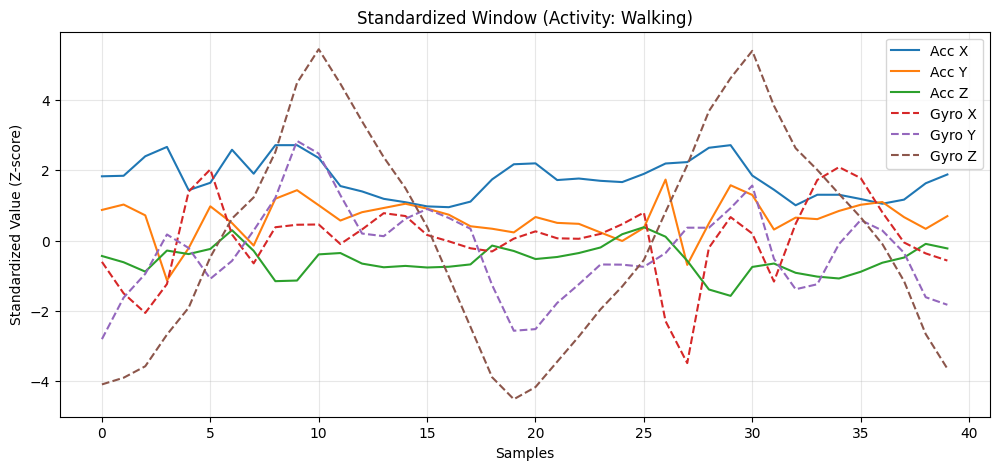

In [13]:
sample_window_scaled = X_scaled[sample_idx]

plt.figure(figsize=(12, 5))
plt.plot(sample_window_scaled[:, :3], label=['Acc X', 'Acc Y', 'Acc Z'])
plt.plot(sample_window_scaled[:, 3:], label=['Gyro X', 'Gyro Y', 'Gyro Z'], linestyle='--')
plt.title(f'Standardized Window (Activity: {sample_label})')
plt.ylabel('Standardized Value (Z-score)')
plt.xlabel('Samples')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

### 5. Saving the Processed Dataset

In [15]:
# Convert sensor data to Float32
X_data = X_scaled.astype('float32')

# Initialize the encoder and transform letters (A, B, C...) to integers (0, 1, 2...)
label_encoder = LabelEncoder()
y_labels_encoded = label_encoder.fit_transform(y)

print("Classes found:", label_encoder.classes_)
print(f"Labels shape: {y_labels_encoded.shape}")

# Define the saving path on Drive
save_path = os.path.join(dataset_dir, 'processed_data')
os.makedirs(save_path, exist_ok=True)

# Save NumPy arrays
np.save(f'{save_path}/X_watch_20Hz_scaled.npy', X_data)
np.save(f'{save_path}/y_watch_labels.npy', y_labels_encoded)

# Save the scaler for future standardization
joblib.dump(scaler, f'{save_path}/wisdm_scaler.pkl')

print(f"\nDataset successfully saved in: {save_path}")
print(f"\nX file: {X_data.shape}, y file: {y_labels_encoded.shape}")

Classes found: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'O' 'P' 'Q' 'R' 'S']
Labels shape: (167247,)

Dataset successfully saved in: ./data/processed_data

X file: (167247, 40, 6), y file: (167247,)


## Dataset Splitting (Train, Validation, Test)
We define a reusable function that wraps train_test_split to partition our processed data into training, validation, and test sets for future use in training notebooks.

In [16]:
def split_and_save_dataset(X, y, train_size=0.7, val_size=0.15, test_size=0.15, random_state=42):
    # First split: separate the training set from the rest
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, train_size=train_size, random_state=random_state, stratify=y
    )

    # Second split: divide the rest into validation and test
    # Calculate the relative proportion for the validation set
    relative_val_size = val_size / (val_size + test_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, train_size=relative_val_size, random_state=random_state, stratify=y_temp
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

## Filtered Dataset: Hand-Oriented Activities
Creation of a subset of the original dataset focused on specific activities: `Dribbling`, `Catch`, `Typing`, `Writing`, `Clapping`, `Teeth`, `Folding`.

In [17]:
# Definition of hand-oriented activities
hand_oriented_activities = ['P', 'O', 'F', 'Q', 'R', 'G', 'S']

# Filter the original dataframe
global_hand_df = global_watch_df[global_watch_df['activity'].isin(hand_oriented_activities)].copy()

print(f"Filtered dataset dimensions: {global_hand_df.shape}")
print("Included activities:")
display(global_hand_df['activity_name'].value_counts())

# Generate windows for the new dataset
X_hand, y_hand = create_windows(global_hand_df, window_size=40, step_size=20)

# Normalization (using the already trained scaler or creating a new one if preferred)
# In this case, we apply the same procedure as before
N_fin, N_samp, N_chan = X_hand.shape
X_hand_reshaped = X_hand.reshape(-1, N_chan)
X_hand_scaled = scaler.transform(X_hand_reshaped).reshape(N_fin, N_samp, N_chan)

# Label encoding
y_hand_encoded = label_encoder.transform(y_hand)

print(f"\nFinal X_hand shape: {X_hand_scaled.shape}")
print(f"Final y_hand shape: {y_hand_encoded.shape}")

Filtered dataset dimensions: (1302960, 10)
Included activities:


,count
activity_name,
Writing,192771
Dribbling,188670
Folding,188367
Teeth,186025
Clapping,185821
Catch,184011
Typing,177295



Final X_hand shape: (64687, 40, 6)
Final y_hand shape: (64687,)


### Saving the Hand-Oriented Dataset
We save the processed files for manual activities only.

In [19]:
# Define the filenames for the hand-oriented subset
save_path_filtered = os.path.join(dataset_dir, 'processed_data/filtered')
os.makedirs(save_path_filtered, exist_ok=True)

file_X_hand = f'{save_path_filtered}/X_hand_20Hz_scaled.npy'
file_y_hand = f'{save_path_filtered}/y_hand_labels.npy'

# Save the arrays
np.save(file_X_hand, X_hand_scaled.astype('float32'))
np.save(file_y_hand, y_hand_encoded)

print(f"Hand-oriented dataset saved successfully!")
print(f"X file saved in: {file_X_hand} - Shape: {X_hand_scaled.shape}")
print(f"y file saved in: {file_y_hand} - Shape: {y_hand_encoded.shape}")

Hand-oriented dataset saved successfully!
X file saved in: ./data/processed_data/filtered/X_hand_20Hz_scaled.npy - Shape: (64687, 40, 6)
y file saved in: ./data/processed_data/filtered/y_hand_labels.npy - Shape: (64687,)
